In [ ]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms

from tqdm import trange

from matplotlib import pyplot as plt

In [2]:
class FourierEncoder(nn.Module):

    def __init__(self, dim):

        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.rand(1, self.half_dim))


    def forward(self, t: torch.Tensor) -> torch.Tensor:

        t = t.view(-1, 1)
        freq = 2 * math.pi * self.weights * t
        sin_embed = torch.sin(freq)
        cos_embed = torch.cos(freq)

        return torch.cat([sin_embed, cos_embed], dim=-1)
    
class Swish(nn.Module):

    def forward(self, x):

        return torch.sigmoid(x) * x



class ResBlock(nn.Module):


    def __init__(self, in_channels, out_channels, time_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.block0 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            Swish(),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1)
        )

        self.proj_time = nn.Sequential(
            Swish(),
            nn.Linear(time_channels, out_channels)
        )

        self.block1 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            Swish(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_embed):

        h = self.block0(x)
        h += self.proj_time(t_embed)[:, :, None, None]
        h = self.block1(h)
        h += self.shortcut(x)
        return h


class DownSample(nn.Module):

    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.down = nn.Conv2d(in_channels, in_channels, 3, 2, 1)

    def forward(self, x, t_embed):
        return self.down(x)
    

class UpSample(nn.Module):

    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.conv = nn.Conv2d(in_channels, in_channels, 3, 1, 1)

    def forward(self, x, t_embed):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels, out_channels, channels, ch_mult, num_res_blocks):
        super().__init__()
        time_channels = channels * 4
        self.time_embedding = FourierEncoder(time_channels)

        self.head = nn.Conv2d(in_channels, channels, 3, 1, 1)

        channels_list = [channels]
        current_channels = channels
        self.downblocks = nn.ModuleList()
        
        for i, mult in enumerate(ch_mult):
            channels_i = channels * mult
            for _ in range(num_res_blocks):
                self.downblocks.append(ResBlock(current_channels, channels_i, time_channels))
                current_channels = channels_i
                channels_list.append(current_channels)
            if i != len(ch_mult) - 1:
                self.downblocks.append(DownSample(current_channels))
                channels_list.append(current_channels)

        self.middleblocks = nn.ModuleList(
            [
                ResBlock(current_channels, current_channels, time_channels),
                ResBlock(current_channels, current_channels, time_channels)
            ]
        )
        
        self.upblocks = nn.ModuleList()

        for i, mult in reversed(list(enumerate(ch_mult))):
            channels_i = channels * mult
            for _ in range(num_res_blocks+1):
                self.upblocks.append(
                    ResBlock(channels_list.pop()+current_channels, channels_i, time_channels)
                )
                current_channels = channels_i
            if i != 0:
                self.upblocks.append(UpSample(current_channels))
        
        assert len(channels_list) == 0

        self.tail = nn.Sequential(
            nn.GroupNorm(8, current_channels),
            Swish(),
            nn.Conv2d(current_channels, out_channels, 3, 1 ,1)
        )


    def forward(self, x, t):
        t_embed = self.time_embedding(t)

        h = self.head(x)
        h_list = [h]
        for block in self.downblocks:
            h = block(h, t_embed)
            h_list.append(h)

        for block in self.middleblocks:
            h = block(h, t_embed)

        for block in self.upblocks:
            if isinstance(block, ResBlock):
                h = torch.cat([h_list.pop(), h], dim=1)
            h = block(h, t_embed)
        
        h = self.tail(h)

        return h

In [3]:
class FlowMatching(nn.Module):


    def __init__(self, flow: nn.Module):

        super().__init__()
        self.flow = flow

    
    def forward(self, z: torch.Tensor, t: torch.Tensor):

        eps = torch.randn_like(z)
        # p_t( | z) = N(a_t*z, b_t^2)
        # a_t = t, b_t = 1-t
        x_t = t * z + (1 - t) * eps

        return self.flow(x_t, t), eps


    def loss(self, z: torch.Tensor):
        t = torch.rand((z.shape[0], 1, 1, 1), device=z.device)
        pred_vel, eps = self.forward(z, t)
        real_vel = z - eps
        error = F.mse_loss(pred_vel, real_vel)
        return error

    
    def sample(self, shape, num_steps=100, device='cpu'):


        x = torch.randn(size=shape, device=device)

        time = torch.linspace(0, 1, num_steps+1)
        with torch.no_grad():
            for i in range(num_steps-1):
                t = torch.full((x.shape[0], 1, 1, 1), time[i], device=x.device)
                h = time[i+1] - time[i]
                x = x + self.flow(x, t) * h
        return x
    

    def sample_with_trajectory(self, shape, num_steps=100, interval=10, device='cpu'):


        x = torch.randn(shape, device=device)
        trajectory = [x]
        time = torch.linspace(0, 1, num_steps+1)
        with torch.no_grad():
            for i in range(num_steps-1):
                t = torch.full((x.shape[0], 1, 1, 1), time[i], device=x.device)
                h = time[i+1] - time[i]
                x = x + self.flow(x, t) * h
                if (i + 1) % interval == 0:
                    trajectory.append(x)
        trajectory.append(x)
        trajectory = torch.cat(trajectory, dim=0)
        return trajectory

In [4]:
# utils

def show_images(images):
    num_samples = len(images)
    plt.figure(figsize=(8, 6))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i+1)
        image = images[i].permute(1, 2, 0)
        plt.imshow(image, cmap='gray')
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# MNIST

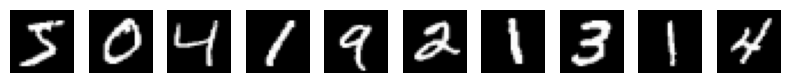

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1305,), (0.2891,)),
])

train_set = torchvision.datasets.MNIST('path/to/data', 
                                       train=True, download=False, transform=transform)

test_set = torchvision.datasets.MNIST('path/to/data', 
                                       train=True, download=False, transform=transform)


num_samples = 10
images = []
for i in range(num_samples):
    image, _ = train_set[i]
    images.append(image)
images = torch.stack(images, dim=0)
show_images(images)

In [6]:
# Config
# Model
in_channels = 1
out_channels = 1
channels = 64
ch_mult = [1, 2, 4]
num_res_blocks = 2

# Training
epochs = 100
batch_size = 128
lr = 5e-4
weight_decay = 1e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'


flow = UNet(in_channels, out_channels, channels, ch_mult, num_res_blocks)

fm = FlowMatching(flow)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)
optimizer = torch.optim.Adam(flow.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, 1e-6)


fm = fm.to(device)

for epoch in (bar := trange(epochs, ncols=88)):
    train_loss, test_loss = 0.0, 0.0
    fm.train()
    for x, y in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        loss = fm.loss(x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    fm.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            loss = fm.loss(x)
            test_loss += loss.item()
    
    num_train_samples = len(train_set)
    num_test_samples = len(test_set)
    train_loss /= num_train_samples
    test_loss /= num_test_samples
    bar.set_postfix(lt=train_loss, lv=test_loss, lr=lr)

    scheduler.step()
    if epoch % 10 == 0:
        torch.save(
                flow.state_dict(),
                f'path/to/weights/mnist-state-{epoch}.pth')
torch.save(
        flow.state_dict(),
        f'path/to/weights/mnist-state.pth')

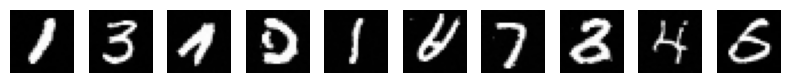

In [ ]:
flow = UNet(in_channels, out_channels, channels, ch_mult, num_res_blocks)

flow.load_state_dict(torch.load('path/to/weights/mnist-state.pth'))

fm = FlowMatching(flow)

fm = fm.to(device)

samples = fm.sample((10, 1, 28, 28), 128, device).detach().cpu()

show_images(samples)

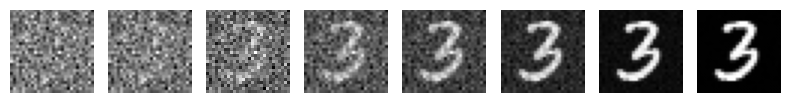

In [9]:
fm = fm.to(device)

trajectory = fm.sample_with_trajectory((1, 1, 28, 28), 128, 20, device).detach().cpu()

show_images(trajectory)